In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
products = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/products.csv')
orders = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/orders.csv',
                     parse_dates=['created_date'])
orderlines = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/orderlines.csv',
                         parse_dates=['date'])
brands = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/brands.csv')
full_df = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/full_df.csv',
                      parse_dates=['date', 'created_date'])


In [3]:
set(full_df.state)

{'Cancelled', 'Completed', 'Pending', 'Place Order', 'Shopping Basket'}

### Price categories

In [66]:
bin_edges = [0, 20, 100, 500, 1000, 1e25]
bin_labels = ['0-20', '20-100', '100-500', '500-1000', 'Above 1000']
full_df['price_category'] = pd.cut(full_df.price, bins=bin_edges, labels=bin_labels)
full_df.price_category.value_counts()

price_category
20-100        115063
100-500        85140
Above 1000     35831
500-1000       21878
0-20           19185
Name: count, dtype: int64

### Add custom columns

c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Axes(0.125,0.11;0.775x0.77)


<Axes: xlabel='date', ylabel='Frequency'>

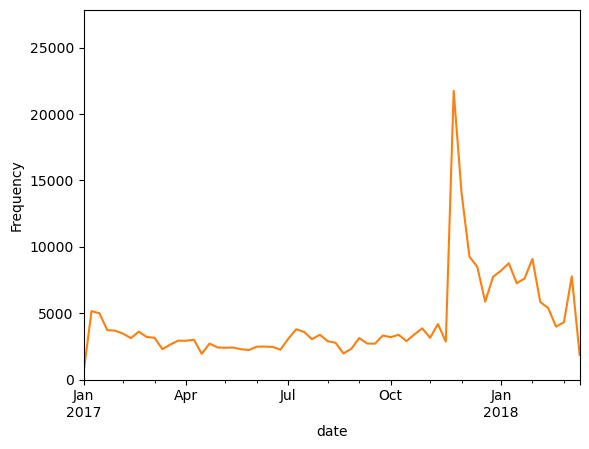

In [ ]:
#Set states that we will use in the analysis
included_states = ['Completed', 'Pending', 'Place Order']

#Add new columns
full_df['discount'] = full_df.price - full_df.unit_price
full_df['discount_per'] = full_df.discount/full_df.price * 100
full_df['ln_quantity'] = np.log (full_df.product_quantity)
full_df['ln_price'] = np.log (full_df.unit_price)
full_df['ln_discount'] = np.log (full_df.discount)

#Remove negative discounts and add only included states
clean_df = full_df[(full_df.state.isin(included_states)) & (full_df.discount > -0.05)]

#Add cleaned_df to the data folder
path = 'C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/clean_df.csv'
clean_df.to_csv(path,index=False)


print(full_df.loc[full_df.discount_per > -20, "discount_per"].plot.hist(bins=100))

#Products sold
full_df.resample('W', on='date').size().plot()



In [ ]:
full_df.resample('W', on='date').size().plot()

type
11865403     8143
11935397     6798
11905404     5352
1364         5196
5384         4004
12215397     3515
12655397     3397
12585395     3270
1231         2871
1230         2701
1296         2637
1405         2631
12175397     2166
1325         2107
1,02E+12     2006
13835403     1892
5,74E+15     1659
51601716     1580
1282         1575
13855401     1508
42945397     1459
12755395     1442
1229         1424
13555403     1415
12635403     1401
13615399     1347
113281716    1284
10142        1263
5398         1233
1433         1218
13005399     1213
12995397     1174
1387         1136
14305406     1086
2,17E+11     1059
57445397     1039
24895185     1017
Name: count, dtype: int64


<Axes: xlabel='type'>

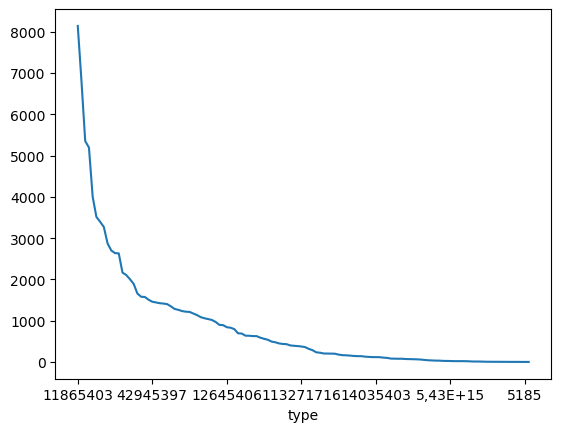

In [73]:
print(clean_df.type.value_counts()[clean_df.type.value_counts()>1000])
clean_df.type.value_counts().plot()

### Are products sold frequently enough to aggregate?

In [33]:
clean_df.groupby(['sku', 'name']).size().nlargest(10)

sku      name                                                                
APP1190  IPhone AppleCare Protection Plan                                        1879
APP0698  Apple Lightning Cable Connector to USB 1m White (OEM)                    871
APP1922  AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch     811
APP0927  EarPods Apple Headphones with Remote and Mic (OEM)                       726
APP1214  Apple Magic Mouse 2                                                      564
WDT0183  Red 4TB WD 35 "Mac PC hard drive and NAS                                 562
SAM0074  Samsung 850 EVO SSD Disk 500GB                                           547
CRU0051  Crucial MX300 525GB SSD Disk                                             454
APP1221  Apple Pencil                                                             438
APP1970  Apple iPhone 32GB Space Gray                                             429
dtype: int64

### Cost of discounting

C:\Users\admin\AppData\Local\Temp\ipykernel_8164\2053898426.py:2: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  weekly_discount = clean_df.resample('w', on='date').agg(total_discount = ('discount', 'sum'), num_orders = ('order_id', 'nunique'))


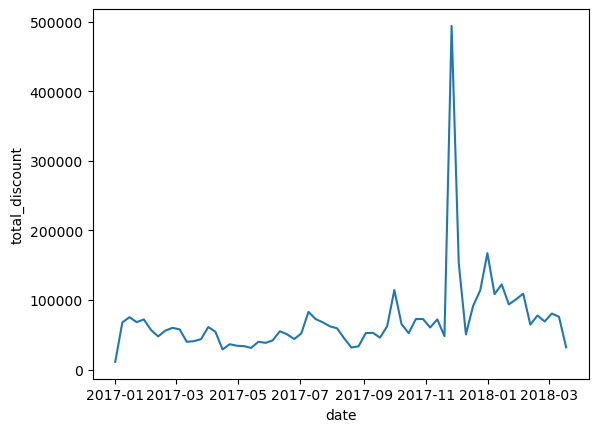

In [ ]:
#total cost of discounts
weekly_discount = clean_df.resample('w', on='date').agg(total_discount = ('discount', 'sum'), num_orders = ('order_id', 'nunique'))
discount_per_oder = weekly_discount.total_discount/weekly_discount.num_orders

#total discount
sns.lineplot(data=weekly_discount.total_discount);

<Axes: xlabel='date'>

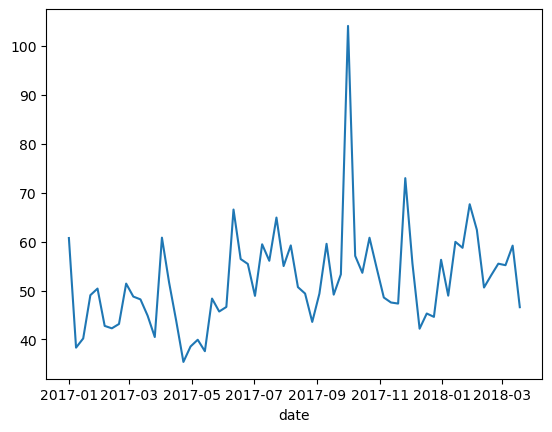

In [ ]:
#discount per order
sns.lineplot(data=discount_per_oder)

c:\Users\admin\anaconda3\Lib\site-packages\numpy\_core\function_base.py:169: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\admin\anaconda3\Lib\site-packages\numpy\_core\function_base.py:179: RuntimeWarning: invalid value encountered in add
  y += start
c:\Users\admin\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


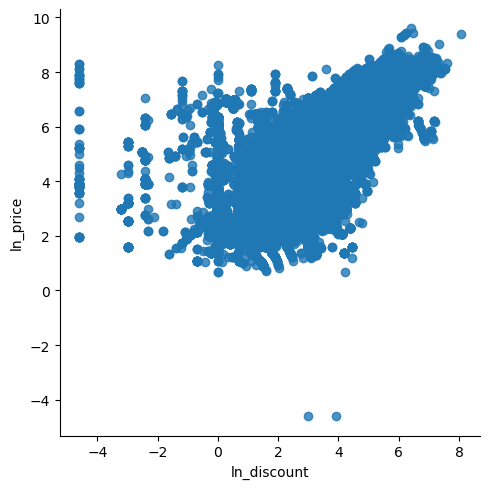

In [68]:
sns.lmplot(data=clean_df, 
           x = 'ln_discount', 
           y= 'ln_price')

### Discounts vs quantity sold for top 10 brands

In [ ]:
#Get a list of brand names
sorted_brands = clean_df[clean_df.state.isin(included_states)].groupby('long')['revenue'].sum().sort_values(ascending=False)
top_10_selling = clean_df[clean_df.state.isin(included_states)].groupby('name')['product_quantity'].sum().sort_values(ascending=False)

In [49]:
#brands = list(set(clean_df.long))
def top_nine_plots(top_series, series_col, title, plot_x='discount_percentage', plot_y = 'quantity_sold', freq='d'):
    plot_data_list = []
    for _brand in top_series.index[0:9]:
        df = clean_df[(clean_df[series_col] == _brand) & (clean_df.state.isin(included_states))]
        plot_data = (df.resample(freq, on= 'date')
            .agg(discount_percentage=("discount_per", "mean"), 
                quantity_sold = ('product_quantity', 'sum'),
                mean_discount = ('discount', 'mean'))
            .reset_index()
        )
        plot_data['log_quantity_sold'] = np.log(plot_data.quantity_sold)
        plot_data['log_discount'] = np.log(plot_data.mean_discount)
        plot_data['brand'] = _brand
        plot_data_list.append(plot_data)
        #plot_data.plot.scatter(x='mean_unit_price', y='quantity_sold')
        # plot = sns.relplot(data=plot_data,
        #             x='discount_percentage',
        #             y='quantity_sold').set(title=_brand)
        # plots.append(plot)

    # Combine all data
    combined_data = pd.concat(plot_data_list, ignore_index=True)

    g = sns.lmplot(data=combined_data,
                    x=plot_x,
                    y=plot_y,
                    col='brand',
                    col_wrap=3,  # 3 plots per row
                    facet_kws={'sharey': False, 'sharex': False})
    g.set_titles("{col_name}")
    g.fig.suptitle(title, 
                fontsize=16, 
                fontweight='bold',
                y=1.02)
    g.set_axis_labels('Discount Percentage (%)', 'Quantity Sold')
# #plt.show()


c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in l

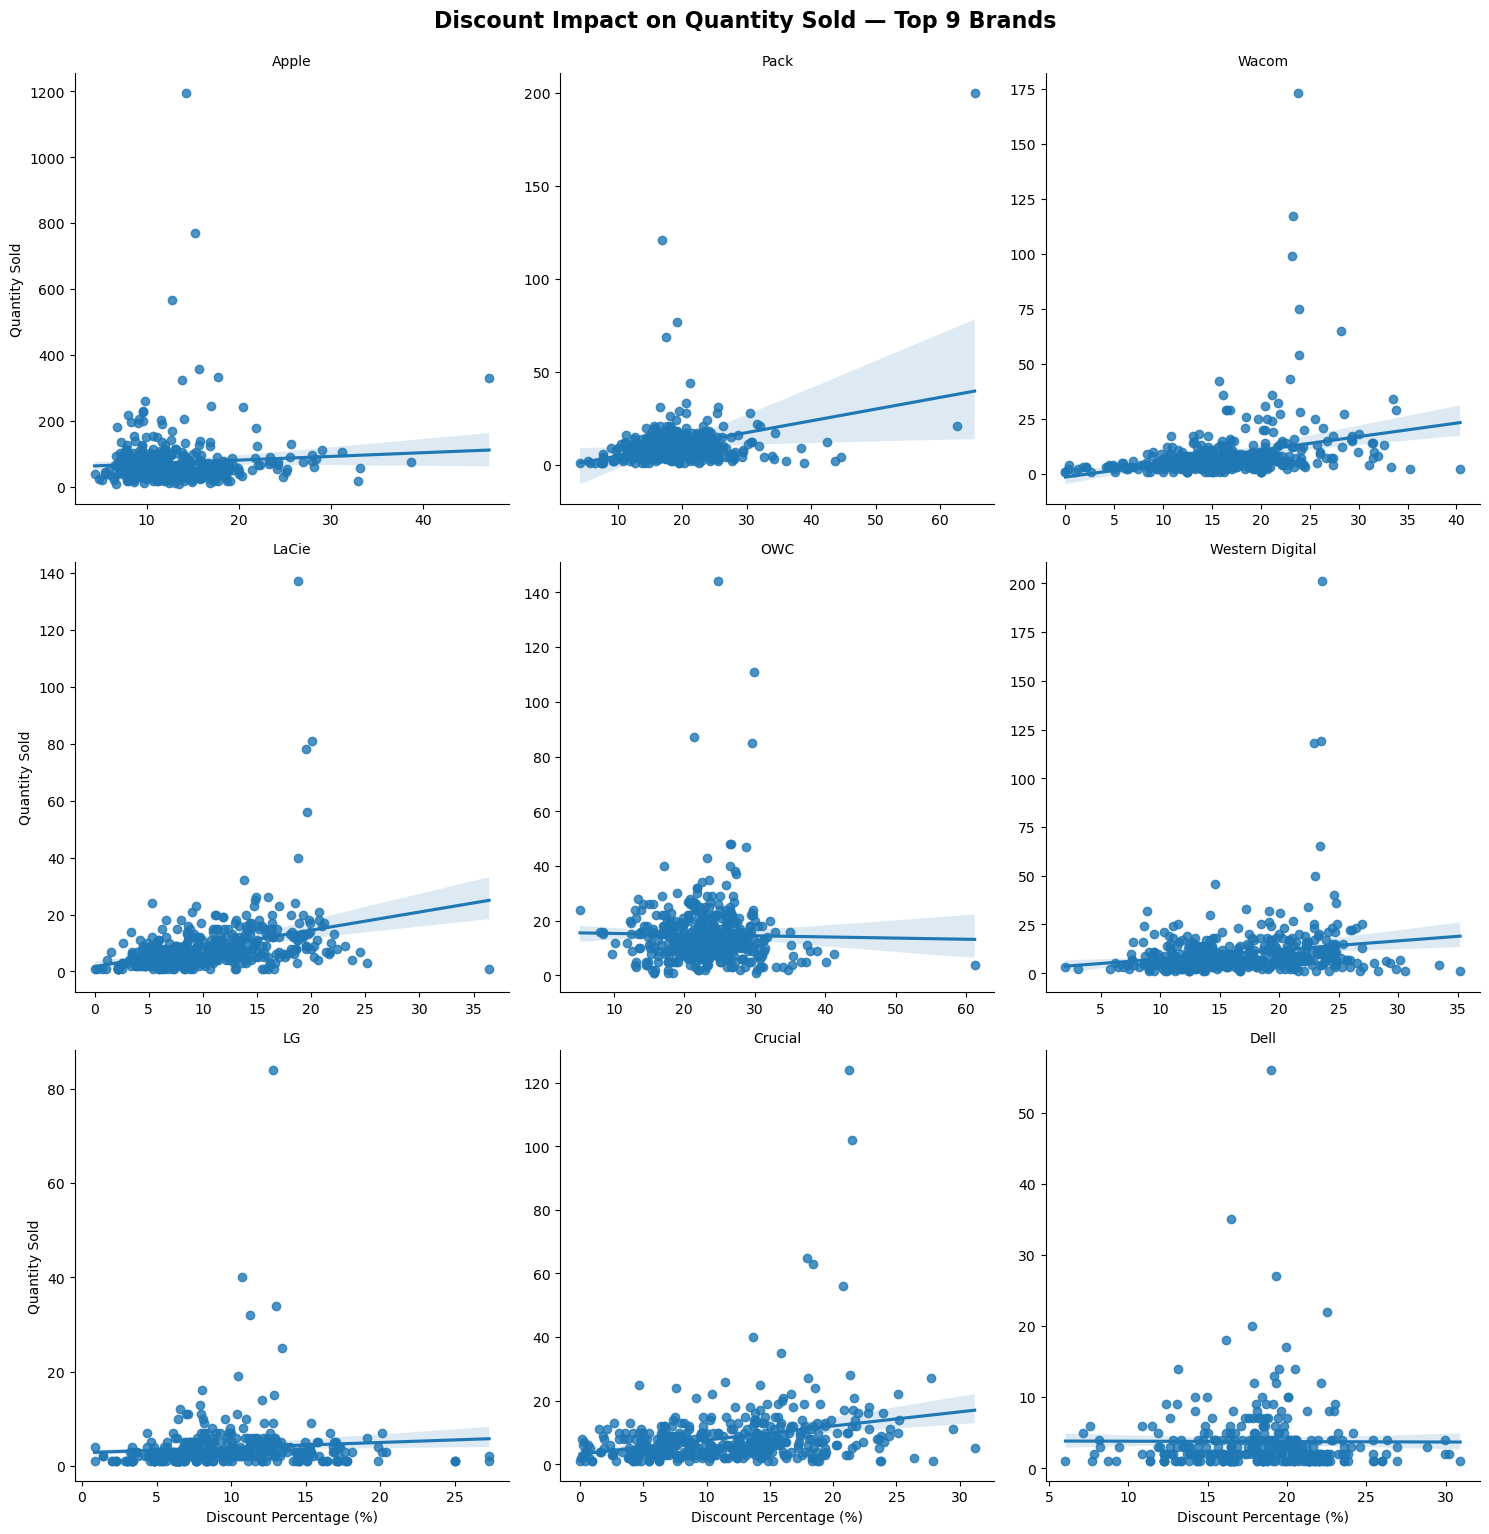

In [50]:
top_nine_plots(sorted_brands, 'long', 'Discount Impact on Quantity Sold — Top 9 Brands')

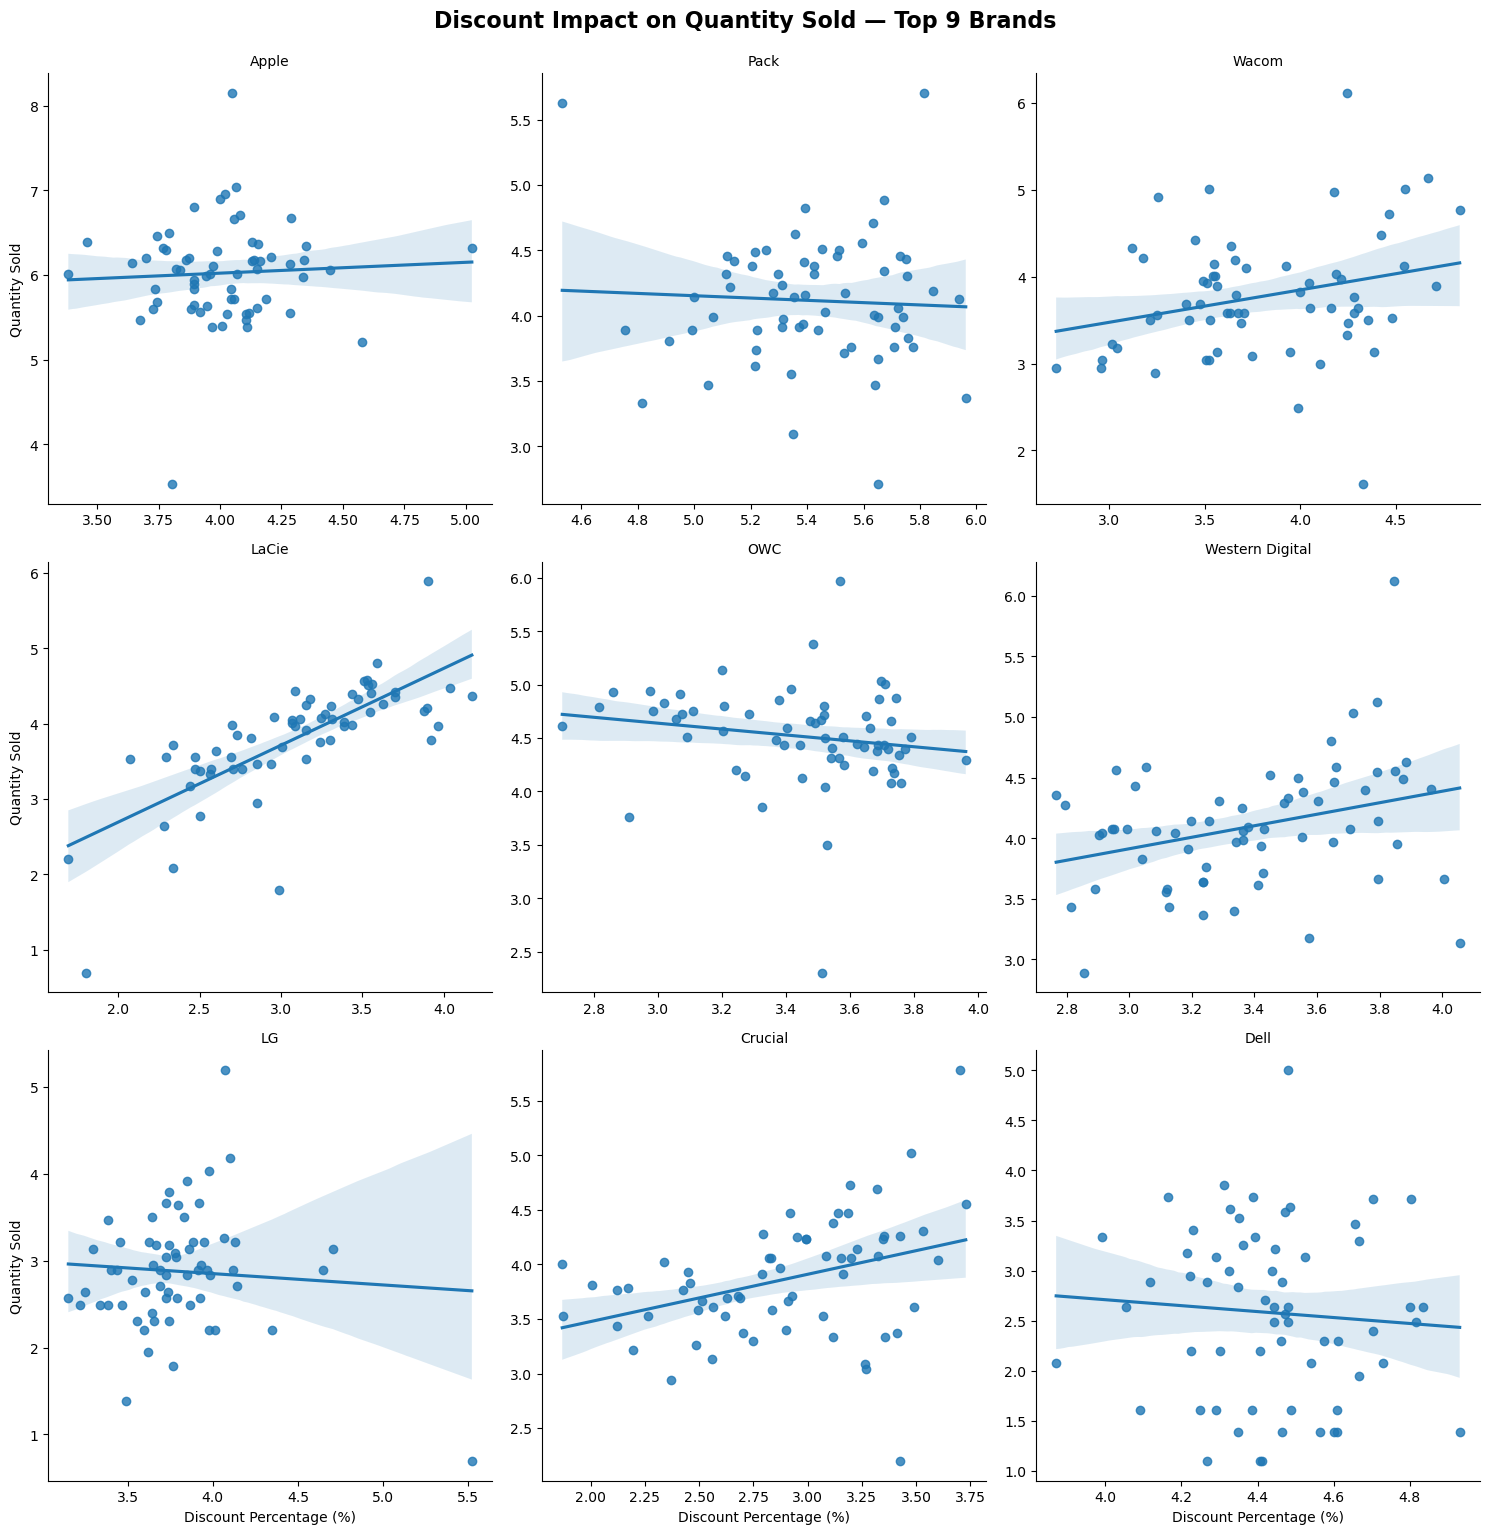

In [51]:
top_nine_plots(sorted_brands, 'long', 'Discount Impact on Quantity Sold — Top 9 Brands', 'log_discount', 'log_quantity_sold', 'W')

c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in l

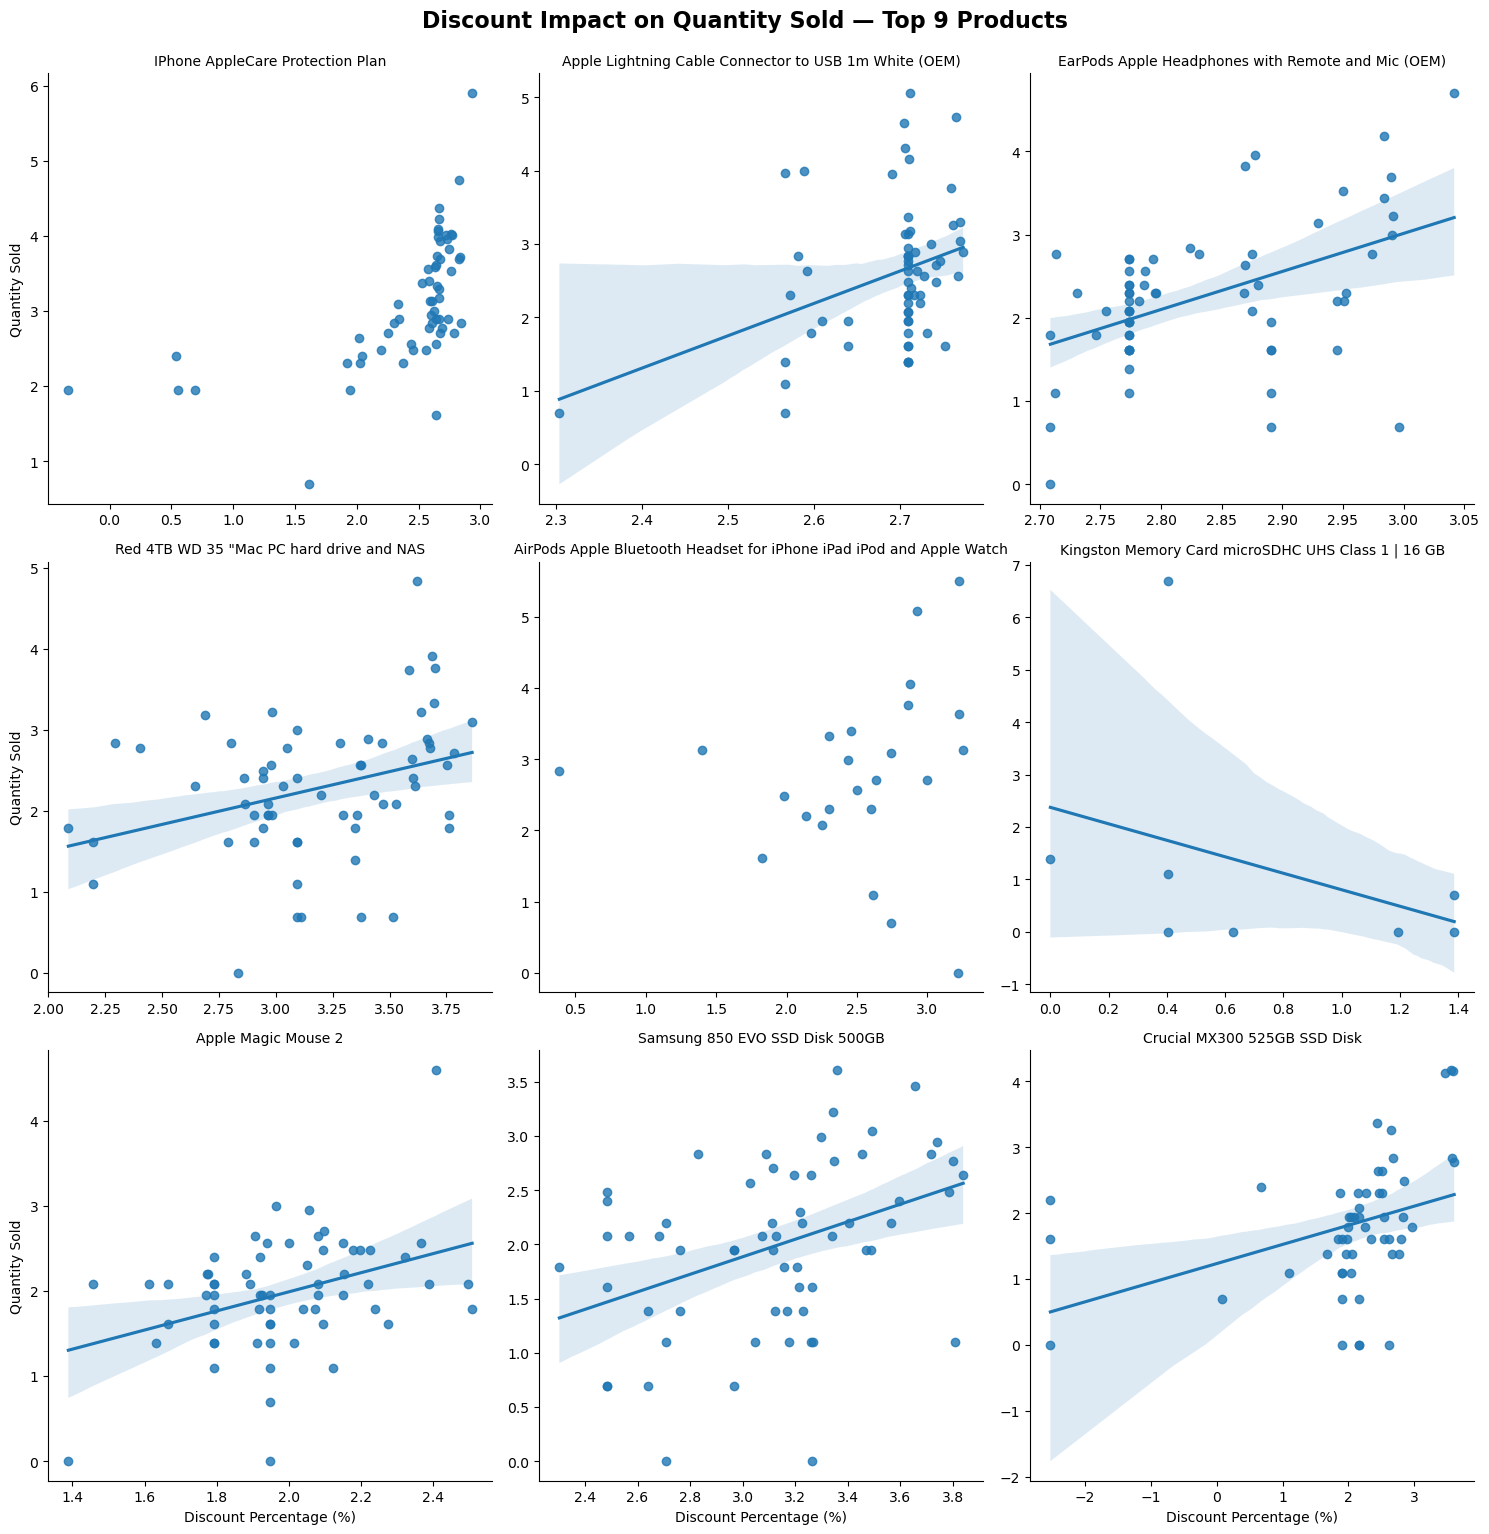

In [46]:
top_nine_plots(top_10_selling, 'name', 'Discount Impact on Quantity Sold — Top 9 Products','log_discount', 'log_quantity_sold', 'W')